## Data subset and baseline configuration.

In [1]:
!wget https://raw.githubusercontent.com/white127/SQUAD-2.0-bidaf/master/evaluate-v2.0.py -O evaluate_v2.py
!pip install rank_bm25 -q


--2026-05-15 17:17:08--  https://raw.githubusercontent.com/white127/SQUAD-2.0-bidaf/master/evaluate-v2.0.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10547 (10K) [text/plain]
Saving to: ‘evaluate_v2.py’

evaluate_v2.py      100%[===================>]  10.30K  --.-KB/s    in 0s      

2026-05-15 17:17:08 (75.4 MB/s) - ‘evaluate_v2.py’ saved [10547/10547]



In [2]:
import json
import urllib.request
import os
import re
from transformers import DistilBertTokenizerFast
from google.colab import userdata
from evaluate_v2 import normalize_answer, compute_exact, compute_f1
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from rank_bm25 import BM25Okapi

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Global preprocessing storage
all_encodings = []
articles = []
train_articles = []
train_encoding_strided, train_input_ids, train_attention_masks, train_start_positions, train_end_positions = [], [], [], [], []
val_articles = []
val_encoding_strided, val_input_ids, val_attention_masks, val_start_positions, val_end_positions = [], [], [], [], []
test_articles = []
test_encoding_strided, test_input_ids, test_attention_masks, test_start_positions, test_end_positions = [], [], [], [], []

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Pre-processing Steps Include:
1.   Load SQuAD and inspect the JSON structure.
2.   Clean only lightly, not aggressively.
3.   Tokenize question and context together with special tokens.
4.   Use truncation and a stride/window approach.
5.   Compute answer start and end offsets.
6.   Create train/validation/test splits.

**Load SQuAD and inspect the JSON structure.**


*   Download Squad V2.0 both training and evaluation data.
*   List keys and investigate first 5 items.
*   Check that every ``answer_start`` offset in the dataset actually points to the correct position in the context string. (Sanity Check)




In [3]:
URLS = {
    "train_v2": "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v2.0.json"
}

for name, url in URLS.items():
    filename = url.split("/")[-1]
    if not os.path.exists(filename):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists, skipping download.")

with open("train-v2.0.json", "r", encoding="utf-8") as f:
    train_v2 = json.load(f)

print(f"SQuAD v2.0 - train articles: {len(train_v2['data'])}")

SQuAD v2.0 - train articles: 442


In [4]:
def print_keys(obj, indent=0):
    prefix = "  " * indent
    if isinstance(obj, dict):
        for key, value in obj.items():
            print(f"{prefix}- {key}")
            print_keys(value, indent + 1)
    elif isinstance(obj, list) and len(obj) > 0:
        print_keys(obj[0], indent + 1)

print("=== SQuAD v2.0 JSON Structure ===")
print_keys(train_v2)

=== SQuAD v2.0 JSON Structure ===
- version
- data
    - title
    - paragraphs
        - qas
            - question
            - id
            - answers
                - text
                - answer_start
            - is_impossible
        - context


In [5]:
count = 0
for article in train_v2["data"]:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            print(json.dumps({
                "title": article["title"],
                "context": para["context"][:150] + "...",
                "question": qa["question"],
                "answer_text": qa["answers"][0]["text"],
                "answer_start": qa["answers"][0]["answer_start"]
            }, indent=2))
            print("-" * 60)
            count += 1
            if count == 5:
                break
        if count == 5:
            break
    if count == 5:
        break

{
  "title": "Beyonc\u00e9",
  "context": "Beyonc\u00e9 Giselle Knowles-Carter (/bi\u02d0\u02c8j\u0252nse\u026a/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Bor...",
  "question": "When did Beyonce start becoming popular?",
  "answer_text": "in the late 1990s",
  "answer_start": 269
}
------------------------------------------------------------
{
  "title": "Beyonc\u00e9",
  "context": "Beyonc\u00e9 Giselle Knowles-Carter (/bi\u02d0\u02c8j\u0252nse\u026a/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Bor...",
  "question": "What areas did Beyonce compete in when she was growing up?",
  "answer_text": "singing and dancing",
  "answer_start": 207
}
------------------------------------------------------------
{
  "title": "Beyonc\u00e9",
  "context": "Beyonc\u00e9 Giselle Knowles-Carter (/bi\u02d0\u02c8j\u0252nse\u026a/ bee-YON-say) (born September 4, 1981) is an American sing

In [6]:
total = 0
mismatches = []
for article in train_v2["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            for ans in qa["answers"]:
                total += 1
                start = ans["answer_start"]
                end = start + len(ans["text"])
                extracted = ctx[start:end]
                if extracted != ans["text"]:
                    mismatches.append({
                        "id": qa["id"],
                        "expected": ans["text"],
                        "got": extracted
                    })

print(f"Checked  : {total} answer spans")
print(f"Mismatches: {len(mismatches)}")

if mismatches:
    print("\nFirst 3 mismatches:")
    for m in mismatches[:3]:
        print(f"  id={m['id']}  expected='{m['expected']}'  got='{m['got']}'")
else:
    print("All spans aligned correctly.")

Checked  : 86821 answer spans
Mismatches: 0
All spans aligned correctly.


**Clean only lightly, not aggressively.**


*    Collapse multiple spaces into one and strips leading/trailing whitespace.
*    Remove unanswerable questions, where ``is_impossible`` field distinguishes v2.0 from v1.1, it flags questions that have no answer in the context.

In [7]:
def clean_dataset(dataset):
    for article in train_v2["data"]:
      for para in article["paragraphs"]:
          para["context"] = re.sub(r" +", " ", para["context"]).strip()
          para["qas"] = [qa for qa in para["qas"] if qa["is_impossible"] == False]
          for qa in para["qas"]:
              qa["question"] = re.sub(r" +", " ", qa["question"]).strip()

    return dataset

In [8]:
train_v2 = clean_dataset(train_v2)

**Tokenize question and context together with special tokens.**
*   CPU time grows fast with sequence length, and a stride/window lets you keep contexts smaller while still preserving answers near boundaries.

In [9]:
def tokenize(sample_question, sample_context):
  document_stride = 128
  encoding_strided = tokenizer(
      sample_question,
      sample_context,
      truncation="only_second",
      max_length=512,
      stride=document_stride,
      return_overflowing_tokens=True,
      padding="max_length",
      return_offsets_mapping=True,
      return_tensors="pt"
  )
  return encoding_strided



In [10]:

sample_question = train_v2["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context  = train_v2["data"][0]["paragraphs"][0]["context"]
encoding_strided = tokenize(sample_question, sample_context)

print(f"Number of chunks produced : {encoding_strided['input_ids'].shape[0]}")
print(f"Each chunk shape          : {encoding_strided['input_ids'].shape[1:]}")

for i in range(encoding_strided['input_ids'].shape[0]):
    tokens = encoding_strided['input_ids'][i].tolist()
    mask = encoding_strided['attention_mask'][i].tolist()
    real_tokens = mask.count(1)
    pad_tokens = mask.count(0)
    print(f"\nChunk {i+1}:")
    print(f"  Real tokens : {real_tokens}")
    print(f"  PAD tokens  : {pad_tokens}")
    print(f"  First 10 decoded: {tokenizer.convert_ids_to_tokens(tokens[:10])}")
    print(f"  Last  10 decoded: {tokenizer.convert_ids_to_tokens(tokens[-10:])}")

Number of chunks produced : 1
Each chunk shape          : torch.Size([512])

Chunk 1:
  Real tokens : 174
  PAD tokens  : 338
  First 10 decoded: ['[CLS]', 'when', 'did', 'beyonce', 'start', 'becoming', 'popular', '?', '[SEP]', 'beyonce']
  Last  10 decoded: ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


**Compute answer start and end offsets**

In [11]:
def offset_mapping(answer, encoding_strided):
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])

    results = []

    for i in range(encoding_strided['input_ids'].shape[0]):
        offsets = encoding_strided['offset_mapping'][i].tolist()
        sequence_ids = encoding_strided.sequence_ids(i)  # tells us which tokens belong to the question (0) and which to the context (1)

        # Find where the context tokens start and end in this chunk
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end = len(sequence_ids) - 1 - next(j for j, s in enumerate(reversed(sequence_ids)) if s == 1)

        # Check if the answer is even inside this chunk
        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            # Walk tokens to find which one contains ans_start and ans_end
            start_pos = next((j for j in range(ctx_start, ctx_end+1) if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start)
            end_pos = next((j for j in range(ctx_end, ctx_start-1, -1) if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end)

        results.append((start_pos, end_pos))

    return results

In [12]:
sample_question = train_v2["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context = train_v2["data"][0]["paragraphs"][0]["context"]
sample_answer = train_v2["data"][0]["paragraphs"][0]["qas"][0]["answers"][0]
encoding_strided = tokenize(sample_question, sample_context)
chunk_positions  = offset_mapping(sample_answer, encoding_strided)

print(f"Question : {sample_question}")
print(f"Answer   : {sample_answer}")
print(f"Context  : {sample_context[:150]}...")
print(f"Chunks   : {len(chunk_positions)}")

for i, (start_pos, end_pos) in enumerate(chunk_positions):
    print(f"\nChunk {i+1}: start_position={start_pos}, end_position={end_pos}")
    tokens = encoding_strided['input_ids'][i].tolist()
    if start_pos != 0 and end_pos != 0:
        predicted_answer = tokenizer.convert_tokens_to_string(
            tokenizer.convert_ids_to_tokens(tokens[start_pos:end_pos+1])
        )
        print(f"  Recovered answer: '{predicted_answer}'")
    else:
        print(f"  Answer not in this chunk")

Question : When did Beyonce start becoming popular?
Answer   : {'text': 'in the late 1990s', 'answer_start': 269}
Context  : Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Bor...
Chunks   : 1

Chunk 1: start_position=75, end_position=78
  Recovered answer: 'in the late 1990s'


*Note: Runnig Time 4-5 minuites*

**Create train/validation/test splits**
*   Split train_v2 into 80/10/10 Splits.
*   Subset Filterin, slice train set down to 50k QA pairs.

In [13]:
import random

# Fix seed for reproducibility
random.seed(42)

# Get all articles and shuffle
articles = train_v2["data"].copy()
random.shuffle(articles)

# Split at article level 80/10/10
total = len(articles)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_articles = articles[:train_end]
val_articles = articles[train_end:val_end]
test_articles = articles[val_end:]

print(f"Train articles      : {len(train_articles)}")
print(f"Validation articles : {len(val_articles)}")
print(f"Test articles       : {len(test_articles)}")

Train articles      : 353
Validation articles : 44
Test articles       : 45


In [14]:
subset_articles = []
qa_count = 0

for article in train_articles:
    article_qa = sum(len(para["qas"]) for para in article["paragraphs"])
    if qa_count <= 50000:
        subset_articles.append(article)
        qa_count += article_qa
    if qa_count >= 50000:
        break

train_articles = subset_articles
print(f"Subset articles : {len(train_articles)}")
print(f"Subset QA pairs : {qa_count}")

Subset articles : 262
Subset QA pairs : 50150


In [15]:
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                train_encoding_strided.append(encoding_strided)
                train_input_ids.append(encoding_strided['input_ids'][i].tolist())
                train_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                train_start_positions.append(start_pos)
                train_end_positions.append(end_pos)

In [16]:
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                val_encoding_strided.append(encoding_strided)
                val_input_ids.append(encoding_strided['input_ids'][i].tolist())
                val_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                val_start_positions.append(start_pos)
                val_end_positions.append(end_pos)

In [17]:
for article in test_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                test_encoding_strided.append(encoding_strided)
                test_input_ids.append(encoding_strided['input_ids'][i].tolist())
                test_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                test_start_positions.append(start_pos)
                test_end_positions.append(end_pos)

In [18]:
print(f"Train chunks      : {len(train_input_ids)}")
print(f"Validation chunks : {len(val_input_ids)}")
print(f"Test chunks       : {len(test_input_ids)}")

Train chunks      : 50230
Validation chunks : 9105
Test chunks       : 9693


In [19]:
def count_qa(articles):
    return sum(
        len(para["qas"])
        for article in articles
        for para in article["paragraphs"]
    )

print(f"Train QA pairs      : {count_qa(train_articles)}")
print(f"Validation QA pairs : {count_qa(val_articles)}")
print(f"Test QA pairs       : {count_qa(test_articles)}")

Train QA pairs      : 50150
Validation QA pairs : 9098
Test QA pairs       : 9671


## Computing baseline EM and F1 scores using the official SQuAD evaluation script



In [20]:
baseline_predictions = {}
em_scores = []
f1_scores = []

for article in val_articles:
    for para in article["paragraphs"]:
        context  = para["context"]
        for qa in para["qas"]:
            question = qa["question"]
            gold_answers = [a["text"] for a in qa["answers"]]

            sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
            if len(sentences) == 0:
                prediction = ""
            elif len(sentences) == 1:
                prediction = sentences[0]
            else:
                tokenized_sentences = [s.lower().split() for s in sentences]
                tokenized_question  = question.lower().split()
                bm25 = BM25Okapi(tokenized_sentences)
                scores = bm25.get_scores(tokenized_question)
                prediction = sentences[np.argmax(scores)]

            baseline_predictions[qa["id"]] = prediction
            em_scores.append(max(compute_exact(a, prediction) for a in gold_answers))
            f1_scores.append(max(compute_f1(a, prediction) for a in gold_answers))

avg_em = sum(em_scores) / len(em_scores) * 100
avg_f1 = sum(f1_scores) / len(f1_scores) * 100

print(f"BM25 Baseline Results on Validation Set")
print(f"Total examples : {len(em_scores)}")
print(f"Exact Match    : {avg_em:.2f}%")
print(f"F1 Score       : {avg_f1:.2f}%")

BM25 Baseline Results on Validation Set
Total examples : 9098
Exact Match    : 0.18%
F1 Score       : 14.96%


In [21]:
sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]
gold        = [a["text"] for a in sample_qa["answers"]]

sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
tokenized_sentences = [s.lower().split() for s in sentences]
tokenized_question  = question.lower().split()
bm25 = BM25Okapi(tokenized_sentences)
scores = bm25.get_scores(tokenized_question)
prediction = sentences[np.argmax(scores)]

print(f"Question    : {question}")
print(f"Gold answers: {gold}")
print(f"Prediction  : {prediction}")
print(f"EM          : {max(compute_exact(a, prediction) for a in gold)}")
print(f"F1          : {max(compute_f1(a, prediction) for a in gold):.4f}")

Question    : When was Gaddafi born, and when did he die?
Gold answers: ['1942 – 20 October 2011']
Prediction  : 1942 – 20 October 2011), commonly known as Colonel Gaddafi,[b] was a Libyan revolutionary, politician, and political theorist.
EM          : 0
F1          : 0.4545


In [22]:
with open("bm25_baseline_predictions.json", "w") as f:
    json.dump(baseline_predictions, f)

# Student B

## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [23]:
import os, time, tracemalloc, random, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hardware ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_CHECKPOINT  = "distilbert-base-uncased"
MAX_SEQ_LENGTH    = 384
STRIDE            = 128
BATCH_SIZE        = 16
GRAD_ACCUM_STEPS  = 2
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
OUTPUT_DIR        = "./distilbert-squad-output"

print("Configuration loaded ✅")

Using device: cuda
Configuration loaded ✅


# load data

In [24]:
# BUG FIX 1: build HuggingFace Datasets from the lists produced by Student A
#             (val_dataset was never defined; Student B referenced a non-existent variable)
# BUG FIX 2: train_input_ids is a plain list, not a Dataset — cannot call .set_format()
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids":       train_input_ids,
    "attention_mask":  train_attention_masks,
    "start_positions": train_start_positions,
    "end_positions":   train_end_positions,
})

val_dataset = Dataset.from_dict({
    "input_ids":       val_input_ids,
    "attention_mask":  val_attention_masks,
    "start_positions": val_start_positions,
    "end_positions":   val_end_positions,
})

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(f"Train dataset : {len(train_dataset):,} chunks")
print(f"Val dataset   : {len(val_dataset):,} chunks")

Train dataset : 50,230 chunks
Val dataset   : 9,105 chunks


## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [25]:
model = DistilBertForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model          : {MODEL_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 6 Transformer encoder layers")
print(f"Hidden size    : 768  |  Heads: 12  |  FFN: 3072")
print()
print(model)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
qa_outputs.bias         | MISSING    | 
qa_outputs.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model          : distilbert-base-uncased
Total params   : 66.4M
Trainable      : 66.4M
Layers         : 6 Transformer encoder layers
Hidden size    : 768  |  Heads: 12  |  FFN: 3072

DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inpla

In [26]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [27]:
#train_dataset = train_dataset.select(range(10000))

## 🏋️ 5. Training + Loss Curves

Starting training...


Epoch,Training Loss,Validation Loss
1,1.361670,1.171845
2,1.163965,1.086416
3,1.015131,1.087497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training complete — wall-clock time: 0.63 hours


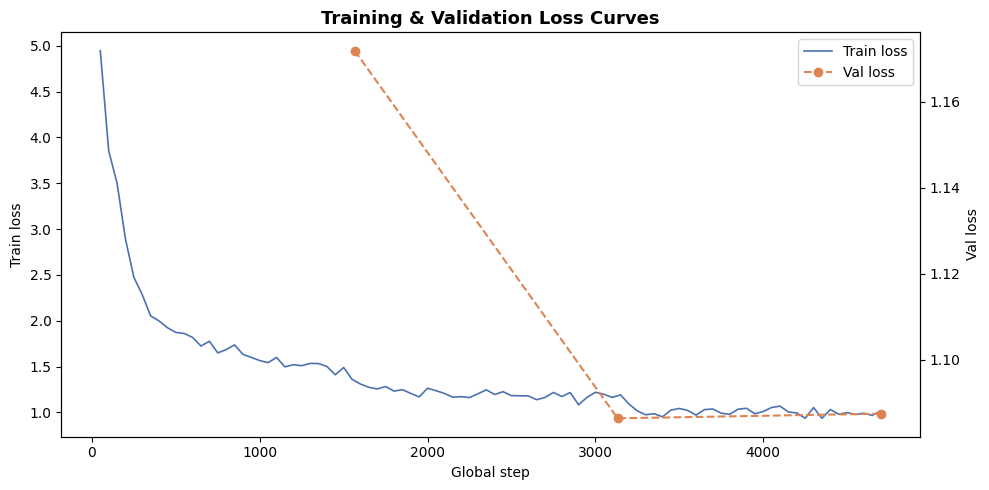

Loss curves saved → loss_curves.png


In [28]:


training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16=True
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = default_data_collator,
)

print("Starting training...")
train_start  = time.time()
train_output = trainer.train()
train_end    = time.time()
wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ Training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ────────────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps  = train_steps[-1] if train_steps else 1
eval_steps_approx  = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → loss_curves.png")

In [29]:
SAVE_PATH = "./distilbert-squad-final"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved → {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved → ./distilbert-squad-final


In [30]:
from transformers import pipeline

qa_pipeline = pipeline("question-answering", model=SAVE_PATH, tokenizer=SAVE_PATH, device=-1)

demos = [
    {"question": "Who introduced BERT?",
     "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. "
                "It achieved state-of-the-art results on eleven NLP tasks."},
    {"question": "How many parameters does DistilBERT have?",
     "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count "
                "by 40%, resulting in approximately 66 million parameters while retaining "
                "97% of BERT's language understanding capability."},
    {"question": "What dataset was used for evaluation?",
     "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 "
                "question-answer pairs from 536 Wikipedia articles."},
]

print("── Inference Demo ──────────────────────────────────────")
for d in demos:
    ans = qa_pipeline(question=d["question"], context=d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {ans['answer']}  (score: {ans['score']:.4f})")
    print()


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

── Inference Demo ──────────────────────────────────────
Q: Who introduced BERT?
A: Devlin  (score: 0.4059)

Q: How many parameters does DistilBERT have?
A: 66 million  (score: 0.7331)

Q: What dataset was used for evaluation?
A: SQuAD v1.1  (score: 0.7324)



In [38]:
import time
import torch

# 1. تحديد الجهاز كـ CPU
device_cpu = torch.device("cpu")

# نقل الموديل للـ CPU
model.to(device_cpu)
model.eval()

# 2. تجهيز سؤال ونص تجريبي

sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

# 3. Tokenization
inputs = tokenizer(
    question,
    context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)

# نقل الـ tensors للـ CPU
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

# 4. قياس زمن الـ inference
start_time = time.time()

with torch.no_grad():
    outputs = model(**inputs)

end_time = time.time()

cpu_latency = (end_time - start_time) * 1000

print(f"✅ Question: {question}")
print(f"🚀 Inference time on CPU: {cpu_latency:.2f} ms")

# لو هتكمل تدريب/تجارب على GPU
# model.to("cuda")

✅ Question: When was Gaddafi born, and when did he die?
🚀 Inference time on CPU: 212.17 ms


# Student C